# Market Basket Analysis — 02 Association Rules (Apriori)

**Support** = how often an itemset appears. **Confidence** = P(consequent | antecedent). **Lift** = confidence ÷ baseline rate (>1 means bought together more than chance). All numbers are run.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils
df=utils.load_transactions(); basket=utils.build_basket(df)
freq,rules=utils.mine_rules(basket,min_support=0.02,min_lift=2.0)
print('frequent itemsets:',len(freq),'| rules (lift>=2):',len(rules))

frequent itemsets: 294 | rules (lift>=2): 312


## 1. Top rules by lift

In [2]:
show=rules.copy()
show['antecedents']=show['antecedents'].apply(lambda s: ', '.join(list(s)))
show['consequents']=show['consequents'].apply(lambda s: ', '.join(list(s)))
show[['antecedents','consequents','support','confidence','lift']].head(10).round(3)

,antecedents,consequents,support,confidence,lift
0,"ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY...",PINK REGENCY TEACUP AND SAUCER,0.032,0.706,15.539
1,PINK REGENCY TEACUP AND SAUCER,"ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY...",0.032,0.708,15.539
2,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,0.032,0.905,15.036
3,GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",0.032,0.534,15.036
4,PINK REGENCY TEACUP AND SAUCER,"REGENCY CAKESTAND 3 TIER, GREEN REGENCY TEACUP...",0.020,0.448,14.837
5,"REGENCY CAKESTAND 3 TIER, GREEN REGENCY TEACUP...",PINK REGENCY TEACUP AND SAUCER,0.020,0.674,14.837
6,GREEN REGENCY TEACUP AND SAUCER,"REGENCY CAKESTAND 3 TIER, PINK REGENCY TEACUP ...",0.020,0.338,14.540
7,"REGENCY CAKESTAND 3 TIER, PINK REGENCY TEACUP ...",GREEN REGENCY TEACUP AND SAUCER,0.020,0.875,14.540
8,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.038,0.826,13.732
9,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.038,0.624,13.732


## 2. Support vs confidence (coloured by lift)

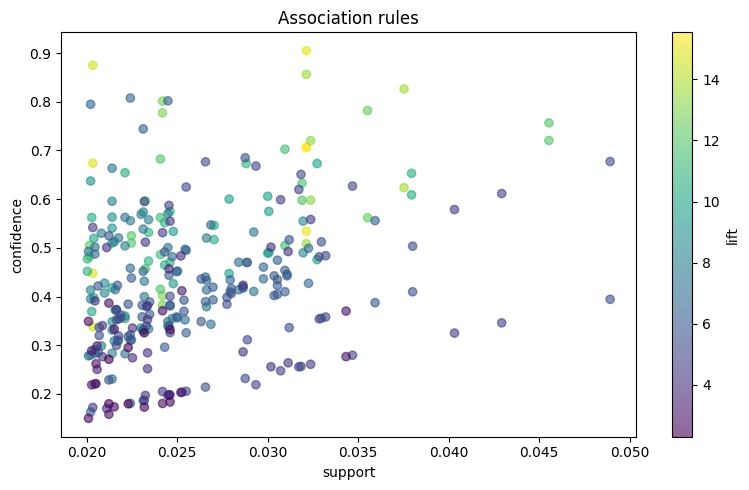

In [3]:
fig,ax=plt.subplots(figsize=(8,5)); sc=ax.scatter(rules.support,rules.confidence,c=rules.lift,cmap='viridis',alpha=0.6); ax.set_xlabel('support'); ax.set_ylabel('confidence'); ax.set_title('Association rules'); plt.colorbar(sc,label='lift'); plt.tight_layout(); plt.show()

## 3. Summary & takeaways

- **312 rules** clear the lift≥2 bar from **294 frequent itemsets** (min support 2%).
- The strongest signal is the **Regency teacup set** — pink/green/roses teacups co-occur with **lift ~15** and confidence up to **0.90**: a customer with two of the three almost always buys the third.
- **Lift, not support, finds the interesting rules** — high-support pairs are often just two individually-popular items; high-lift pairs reveal genuine complementarity (sets, bundles).
- Actionable: bundle/cross-sell the teacup set and similar high-lift groups; place them together.